Simulation_Edge_true: Ea=0.8084 eV, D0=1.11e-08 m^2/s, R2=0.990
Simulation_Screw_true: Ea=0.9129 eV, D0=2.43e-10 m^2/s, R2=0.936
Simulation_EdgeDislocation_0v: Ea=0.8300 eV, D0=2.81e-09 m^2/s, R2=0.969
Bulk_Experiments: Ea=1.3719 eV, D0=1.23e-07 m^2/s, R2=0.963


C:\Users\dd03\AppData\Local\Temp\ipykernel_27968\1005263423.py:72: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(scaled_x, D, label=display_name, color=colors[i],


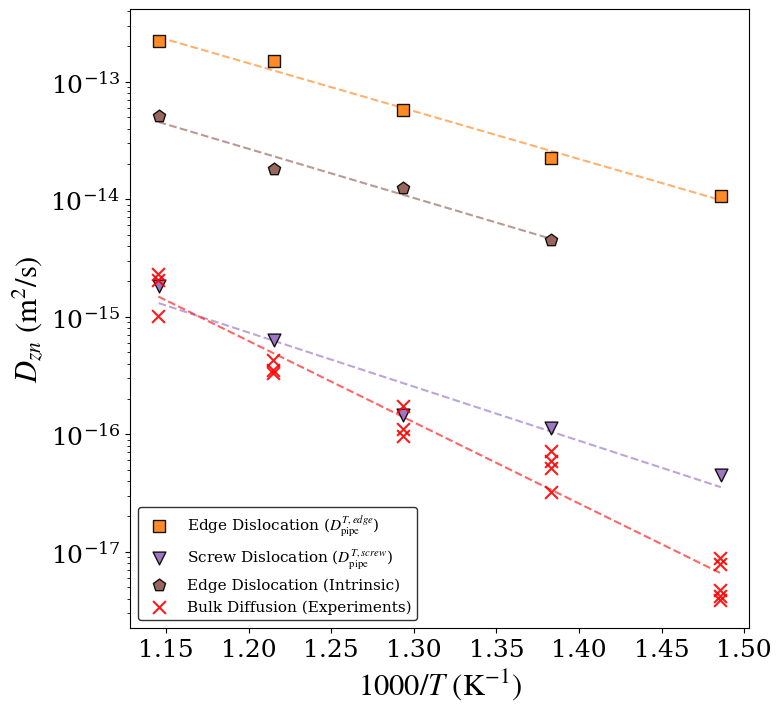

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.ticker as ticker

# 1. Configuration
excel_file = 'Arrhenius_to_plot.xlsx'

# Updated Sheets list
sheets = [
    "Simulation_Edge_true", 
    "Simulation_Screw_true",
    "Simulation_EdgeDislocation_0v",
    "Bulk_Experiments"
]

# --- MANUALLY CHANGE LEGEND NAMES HERE ---
legend_mapping = {
    
    "Simulation_Edge_true": r"Edge Dislocation ($D_{\text{pipe}}^{T,edge}$)",
    "Simulation_Screw_true": r"Screw Dislocation ($D_{\text{pipe}}^{T,screw}$)",
    "Simulation_EdgeDislocation_0v": "Edge Dislocation (Intrinsic)",
    "Bulk_Experiments": "Bulk Diffusion (Experiments)"
}

k_B = 8.617333262e-5  # Boltzmann constant in eV/K

# 2. Styling
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'mathtext.fontset': 'stix'
})

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_box_aspect(1) 

# Colors and markers for all 6 datasets
colors = [ '#ff7f0e', '#9467bd', '#8c564b', 'red']
markers = [ 's', 'v', 'p', 'x']

# 3. Calculations and Plotting
for i, sheet in enumerate(sheets):
    try:
        df = pd.read_excel(excel_file, sheet_name=sheet)
        
        # Auto-detect columns
        temp_col = [c for c in df.columns if 'temp' in c.lower()][0]
        diff_col = [c for c in df.columns if 'dzn' in c.lower() or 'diff' in c.lower()][0]
        
        T = df[temp_col]
        D = df[diff_col]
        
        # Regression in ln(D) vs 1/T space
        inv_T = 1.0 / T
        ln_D = np.log(D)
        slope, intercept, r_val, _, _ = stats.linregress(inv_T, ln_D)
        
        scaled_x = 1000.0 / T
        
        # Physics Parameters for console
        Ea = -slope * k_B
        D0 = np.exp(intercept)
        print(f"{sheet}: Ea={Ea:.4f} eV, D0={D0:.2e} m^2/s, R2={r_val**2:.3f}")
        
        # --- LOGIC TO CHANGE LEGEND NAME ---
        # It looks up the sheet name in our dictionary above
        display_name = legend_mapping.get(sheet, sheet)
        
        # Plot Scatter (Raw D values)
        ax.scatter(scaled_x, D, label=display_name, color=colors[i], 
                    marker=markers[i], s=85, edgecolors='k', alpha=0.9, zorder=5)
        
        # Plot Fit Line
        m_scaled, b_scaled, _, _, _ = stats.linregress(scaled_x, ln_D)
        x_fit = np.linspace(scaled_x.min(), scaled_x.max(), 100)
        y_fit = np.exp(b_scaled + m_scaled * x_fit)
        
        ax.plot(x_fit, y_fit, color=colors[i], linestyle='--', alpha=0.6)
        
    except Exception as e:
        print(f"Skipping {sheet}: {e}")

# 4. Logarithmic Y-Axis Setup
ax.set_yscale('log')
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=12))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# 5. Final Layout - Grid Control
ax.set_xlabel(r'$1000 / T \ (\mathrm{K}^{-1})$', fontweight='bold', fontsize=22)
ax.set_ylabel(r'$D_{zn} \ (\mathrm{m}^2/\mathrm{s})$', fontweight='bold', fontsize=22)
plt.xticks(fontsize=18) # Adjust this number to your preferred size

plt.yticks(fontsize=18) # Adjust this number to your preferred size
ax.legend(loc='best', frameon=True, fontsize=11, edgecolor='k')

#ax.grid(True, which="major", linestyle='-', alpha=0.3)
ax.grid(False, which="minor") 

plt.tight_layout()
plt.savefig('Arrhenius_Clean_Log_True_diffusion.png', dpi=300)